First 5 Rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values

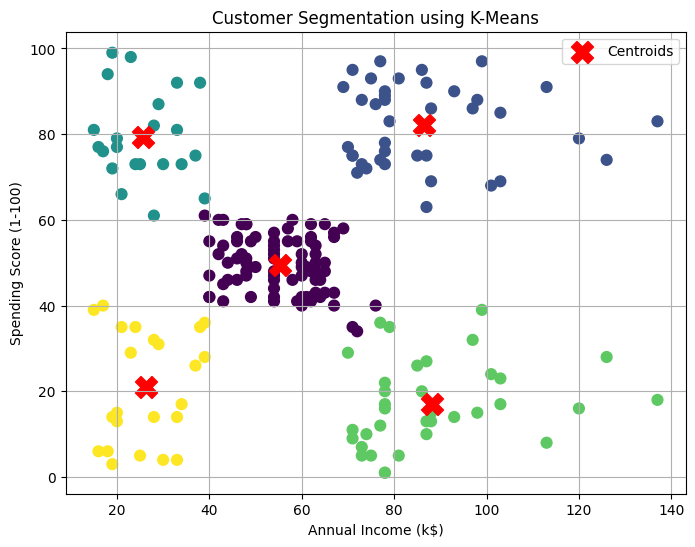


Customers in Each Cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [1]:
# ==========================================
# Customer Segmentation Analysis using K-Means
# ==========================================

# Step 1: Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 2: Load Dataset

df = pd.read_csv("Mall_Customers.csv")

# Step 3: Display First Five Rows

print("First 5 Rows:")
print(df.head())

# Step 4: Dataset Information

print("\nDataset Information:")
print(df.info())

# Step 5: Check Missing Values

print("\nMissing Values:")
print(df.isnull().sum())

# Step 6: Remove Unnecessary Column

df = df.drop("CustomerID", axis=1)

# Step 7: Select Features for Clustering

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 8: Apply K-Means Clustering

kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

# Step 9: Display Clustered Data

print("\nClustered Data:")
print(df.head())

# Step 10: Plot Customer Clusters

plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    s=60
)

# Plot Cluster Centers

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=250,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()

# Step 11: Number of Customers in Each Cluster
print("\nCustomers in Each Cluster:")
print(df['Cluster'].value_counts().sort_index())

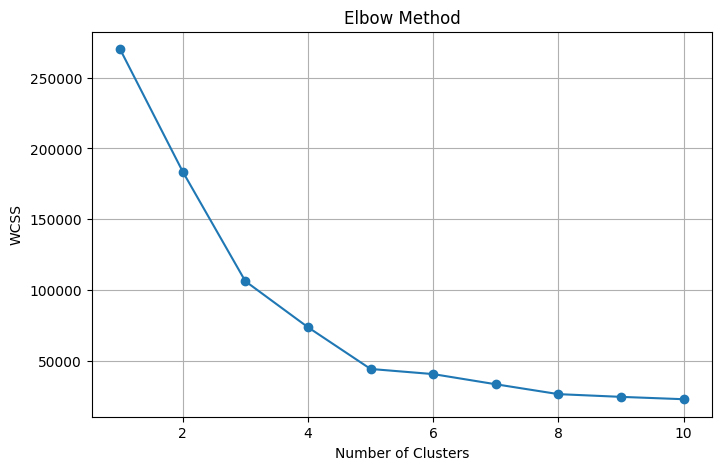

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()